In [24]:
import pandas as pd
import numpy as np
import re
import string
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [30]:
df = pd.read_csv(r"C:\Users\saibh\resumeAnalyzer\dataset\resume_data.csv") 

In [32]:
print(df.columns)


Index(['address', 'career_objective', 'skills', 'educational_institution_name',
       'degree_names', 'passing_years', 'educational_results', 'result_types',
       'major_field_of_studies', 'professional_company_names', 'company_urls',
       'start_dates', 'end_dates', 'related_skils_in_job', 'positions',
       'locations', 'responsibilities', 'extra_curricular_activity_types',
       'extra_curricular_organization_names',
       'extra_curricular_organization_links', 'role_positions', 'languages',
       'proficiency_levels', 'certification_providers', 'certification_skills',
       'online_links', 'issue_dates', 'expiry_dates', '﻿job_position_name',
       'educationaL_requirements', 'experiencere_requirement',
       'age_requirement', 'responsibilities.1', 'skills_required',
       'matched_score'],
      dtype='object')


In [34]:
df['resume_text'] = (
    df['career_objective'].fillna('') + " " +
    df['skills'].fillna('') + " " +
    df['responsibilities'].fillna('')
)

In [36]:
df.rename(columns={'﻿job_position_name': 'job_position_name'}, inplace=True)

In [38]:
df = df[['resume_text', 'job_position_name']].dropna()

print("Total records:", len(df))


Total records: 9544


In [40]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df['cleaned_resume'] = df['resume_text'].apply(clean_text)

In [42]:
label_encoder = LabelEncoder()
df['encoded_category'] = label_encoder.fit_transform(df['job_position_name'])

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_resume'],
    df['encoded_category'],
    test_size=0.2,
    random_state=42
)

In [46]:
tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [47]:
model = LogisticRegression(max_iter=300)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=300)

In [50]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Model Accuracy: 100.0 %

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        74
           1       1.00      1.00      1.00        68
           2       1.00      1.00      1.00        62
           3       1.00      1.00      1.00        69
           4       1.00      1.00      1.00        70
           5       1.00      1.00      1.00        68
           6       1.00      1.00      1.00        59
           7       1.00      1.00      1.00        71
           8       1.00      1.00      1.00        62
           9       1.00      1.00      1.00        80
          10       1.00      1.00      1.00        64
          11       1.00      1.00      1.00        55
          12       1.00      1.00      1.00        62
          13       1.00      1.00      1.00        78
          14       1.00      1.00      1.00        75
          15       1.00      1.00      1.00        78
          16       1.00      1.

In [52]:
print(df['job_position_name'].nunique())

28


In [54]:
print(df['job_position_name'].value_counts())

job_position_name
Site Engineer                                                                              342
Project Coordinator (Civil)                                                                342
Civil Engineer                                                                             342
HR Officer                                                                                 342
Marketing Officer                                                                          341
Manager- Human Resource Management (HRM)\n                                                 341
Head of Internal Control & Compliance (ICC) - SEVP/DMD                                     341
Management Trainee - Mechanical                                                            341
Sr.Officer / Executive - Internal Audit                                                    341
Executive - VAT                                                                            341
Network Support Engineer        

In [56]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 7635
Testing samples: 1909


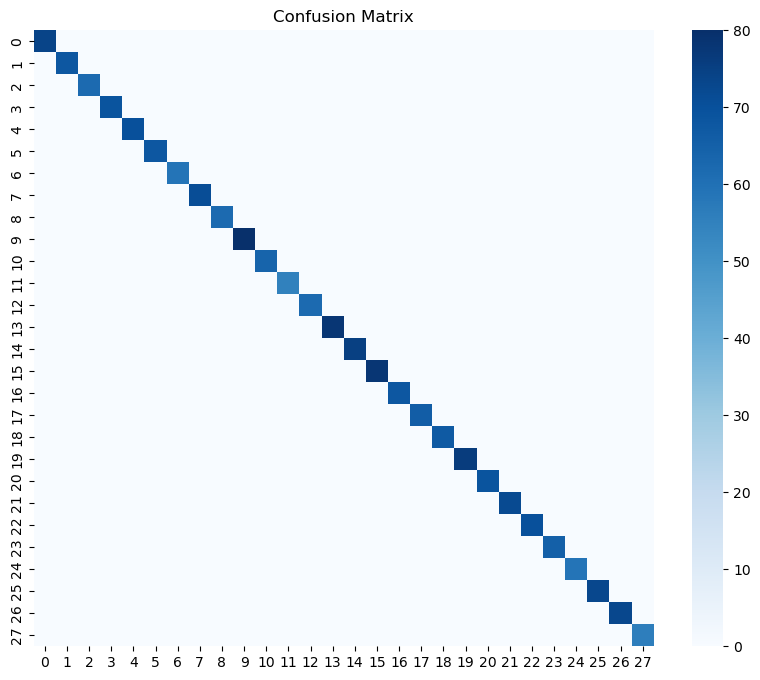

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [59]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train_tfidf, y_train, cv=5)

print("Cross validation accuracy:", scores)
print("Average accuracy:", scores.mean())

Cross validation accuracy: [0.99869024 0.99934512 0.99934512 0.99934512 1.        ]
Average accuracy: 0.9993451211525868


In [60]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

models = {

    "Logistic Regression": LogisticRegression(max_iter=300),

    "Naive Bayes": MultinomialNB(),

    "Support Vector Machine": LinearSVC(),

    "Random Forest": RandomForestClassifier(n_estimators=100),

    "Decision Tree": DecisionTreeClassifier()

}

results = {}

for name, model in models.items():

    print("\n==============================")
    print("Training:", name)
    print("==============================")

    model.fit(X_train_tfidf, y_train)

    y_pred = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy

    print("Accuracy:", round(accuracy * 100, 2), "%")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Training: Logistic Regression
Accuracy: 100.0 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        74
           1       1.00      1.00      1.00        68
           2       1.00      1.00      1.00        62
           3       1.00      1.00      1.00        69
           4       1.00      1.00      1.00        70
           5       1.00      1.00      1.00        68
           6       1.00      1.00      1.00        59
           7       1.00      1.00      1.00        71
           8       1.00      1.00      1.00        62
           9       1.00      1.00      1.00        80
          10       1.00      1.00      1.00        64
          11       1.00      1.00      1.00        55
          12       1.00      1.00      1.00        62
          13       1.00      1.00      1.00        78
          14       1.00      1.00      1.00        75
          15       1.00      1.00      1.00        78
        

In [61]:
df['job_position_name'].value_counts().head(20)

job_position_name
Site Engineer                                                                              342
Project Coordinator (Civil)                                                                342
Civil Engineer                                                                             342
HR Officer                                                                                 342
Marketing Officer                                                                          341
Manager- Human Resource Management (HRM)\n                                                 341
Head of Internal Control & Compliance (ICC) - SEVP/DMD                                     341
Management Trainee - Mechanical                                                            341
Sr.Officer / Executive - Internal Audit                                                    341
Executive - VAT                                                                            341
Network Support Engineer        